In [20]:
import time
import cv2
import mediapipe as mp
import numpy as np
from matplotlib import pyplot as plt

# MediaPipe 버전 확인
print(f"MediaPipe Version: {mp.__version__}")

# MediaPipe Solutions 초기화
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=2,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.5
)

print("OK: solutions setup ready")

MediaPipe Version: 0.10.15
OK: solutions setup ready


I0000 00:00:1778739753.296021  105300 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2


In [21]:
# 카메라가 열리는지 먼저 확인
import os
import cv2
import matplotlib.pyplot as plt

def find_internal_camera():
    for i in range(10):  # 최대 10개의 카메라 장치를 확인
        cap = cv2.VideoCapture(i)
        if cap.isOpened():
            ret, frame = cap.read()
            if ret:
                # 내부 카메라를 식별하기 위해 해상도 또는 특정 패턴 확인
                if frame.shape[0] > 480:  # 내부 카메라의 해상도가 더 높을 가능성
                    print(f"내부 카메라로 추정되는 장치: {i}")
                    cap.release()
                    return i
            cap.release()
    return -1

def stream_internal_camera():
    camera_index = find_internal_camera()
    if camera_index == -1:
        raise RuntimeError("내부 카메라를 찾을 수 없습니다.")

    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened():
        raise RuntimeError("카메라를 열 수 없습니다. 권한/디바이스 확인 필요")

    print("카메라가 성공적으로 열렸습니다. 'q'를 눌러 종료하세요.")
    while True:
        ret, frame = cap.read()
        if not ret:
            print("프레임을 가져올 수 없습니다.")
            break
        cv2.imshow('Internal Camera', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            print("카메라 스트림을 종료합니다.")
            break
    cap.release()
    cv2.destroyAllWindows()

W0000 00:00:1778739753.309511  275383 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


프레임 1/30 처리 중...
프레임 2/30 처리 중...


W0000 00:00:1778739753.322375  275383 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


프레임 3/30 처리 중...
프레임 4/30 처리 중...
프레임 5/30 처리 중...
프레임 6/30 처리 중...
프레임 7/30 처리 중...
프레임 8/30 처리 중...
프레임 9/30 처리 중...
프레임 10/30 처리 중...
프레임 11/30 처리 중...
프레임 12/30 처리 중...
프레임 13/30 처리 중...
프레임 14/30 처리 중...
프레임 15/30 처리 중...
프레임 16/30 처리 중...
프레임 17/30 처리 중...
프레임 18/30 처리 중...
프레임 19/30 처리 중...
프레임 20/30 처리 중...
프레임 21/30 처리 중...
프레임 22/30 처리 중...
프레임 23/30 처리 중...
프레임 24/30 처리 중...
프레임 25/30 처리 중...
프레임 26/30 처리 중...
프레임 27/30 처리 중...
프레임 28/30 처리 중...
프레임 29/30 처리 중...
프레임 30/30 처리 중...


/Users/leejimin/2026-capstone-31/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/leejimin/2026-capstone-31/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/leejimin/2026-capstone-31/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/leejimin/2026-capstone-31/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/leejimin/2026-capstone-31/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:1

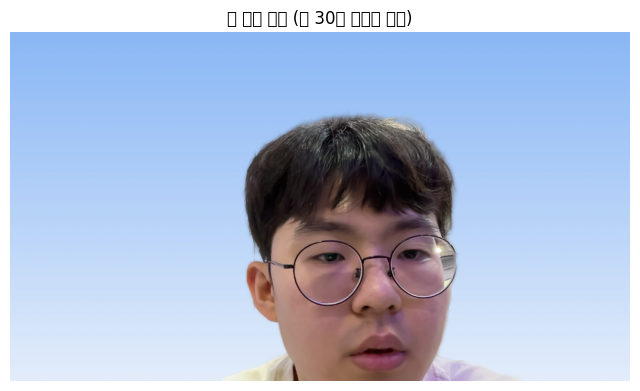

In [22]:
# MediaPipe Solutions 기반 실시간 손 인식
def detect_hands_webcam(num_frames=30):
    """웹캠에서 num_frames개 프레임을 캡처하고 마지막 결과를 표시"""
    cap = cv2.VideoCapture(0)
    frames_captured = 0
    last_frame = None

    while cap.isOpened() and frames_captured < num_frames:
        ret, frame = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = hands.process(frame_rgb)

        if results.multi_hand_landmarks:
            h, w, _ = frame.shape
            for hand_landmarks in results.multi_hand_landmarks:
                for lm in hand_landmarks.landmark:
                    x, y = int(lm.x * w), int(lm.y * h)
                    cv2.circle(frame, (x, y), 3, (0, 255, 0), -1)

        last_frame = frame
        frames_captured += 1
        print(f"프레임 {frames_captured}/{num_frames} 처리 중...")

    cap.release()
    
    if last_frame is not None:
        plt.figure(figsize=(8, 6))
        plt.imshow(cv2.cvtColor(last_frame, cv2.COLOR_BGR2RGB))
        plt.title(f"손 감지 결과 (총 {frames_captured}개 프레임 처리)")
        plt.axis("off")
        plt.show()

# 실행
detect_hands_webcam()

In [ ]:
# 내부 카메라 스트림 테스트 및 손 인식
def test_hand_detection():
    camera_index = find_internal_camera()
    if camera_index == -1:
        raise RuntimeError("내부 카메라를 찾을 수 없습니다.")

    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened():
        raise RuntimeError("카메라를 열 수 없습니다. 권한/디바이스 확인 필요")

    print("손 인식 테스트를 시작합니다. 'q'를 눌러 종료하세요.")
    while True:
        ret, frame = cap.read()
        if not ret:
            print("프레임을 가져올 수 없습니다.")
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = hands.process(frame_rgb)

        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                mp_drawing.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

        cv2.imshow('Hand Detection', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            print("손 인식 테스트를 종료합니다.")
            break

    cap.release()
    cv2.destroyAllWindows()

# 실행
test_hand_detection()ㅂ

내부 카메라로 추정되는 장치: 0
손 인식 테스트를 시작합니다. 'q'를 눌러 종료하세요.


W0000 00:00:1778739759.606291  275385 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
/Users/leejimin/2026-capstone-31/.venv/lib/python3.9/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


손 인식 테스트를 종료합니다.


: 